In [2]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
from os import listdir
import tensorflow as tf
from numpy import pi as PI
from keras.layers import Dense
import matplotlib.pyplot as plt
from os.path import join, exists
from sklearn.utils import shuffle
from keras.models import Sequential
from tensorflow.keras.regularizers import l2
# from cmsisdsp import arm_cos_f32, arm_float_to_q15
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.initializers import RandomUniform
from keras.layers import Conv2D, MaxPooling2D, Flatten
# from cmsisdsp import arm_mult_q15, arm_rfft_instance_q15, arm_rfft_init_q15, arm_rfft_q15, arm_cmplx_mag_q15

In [26]:
SAMPLING_FREQUENCY = 8000
MAX_LEN = 8000
WINDOW_SIZE = 256
STEP_SIZE = 128
NUM_WINDOWS = int(1 + (SAMPLING_FREQUENCY - WINDOW_SIZE) // STEP_SIZE)
NUM_FFT_BINS = int(WINDOW_SIZE // 2 + 1)

UNITS = 25
LEARNING_RATE = 0.01 
NUM_CLASSES = 2
EPOCHS = 20 
BATCH_SIZE = 32
# IN_SHAPE = (8000,)
IN_SHAPE = (61, 129)
VALIDATION_SIZE = 0.25

In [4]:
def create_folder(directory):
    if not exists(directory):
        os.makedirs(directory)

In [5]:
create_folder("./saved_models")

In [36]:
DATA_PATH = "/home/icfoss/Datasets/kws_data/archive/"
SAVED_MODEL_PATH = join("./saved_models","dnn_model.keras")
SELECTED_KEYWORDS = ["yes", "no"]
all_paths = []

yes_audios = listdir(join(DATA_PATH, "yes"))
no_audios = listdir(join(DATA_PATH, "no"))

for yes_audio in yes_audios:
    yes_path = join(join(DATA_PATH, "yes"), yes_audio)
    all_paths.append([yes_path, "yes"])

for no_audio in no_audios:
    no_path = join(join(DATA_PATH, "no"), no_audio)
    all_paths.append([no_path, "no"])
    
basic_data = pd.DataFrame(all_paths, columns=["Path", "Label"])

In [7]:
basic_data = shuffle(basic_data, random_state=33)
basic_data.loc[basic_data["Label"] == "yes", "Label"] = 1
basic_data.loc[basic_data["Label"] == "no", "Label"] = 0

In [8]:
stat = basic_data["Label"].value_counts()
print(stat*100/stat.sum())

Label
1    50.644959
0    49.355041
Name: count, dtype: float64


In [9]:
X = basic_data["Path"]
y = basic_data["Label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=45, stratify=y)

In [10]:
def read_and_pad_seq(X, max_length=8000):
    X_seq = np.empty((0, max_length), float)
    for index, file_path in tqdm(X.items(), total = X.shape[0]): 
        audio_segment, _ = librosa.load(file_path, sr=8000)
        k = audio_segment.shape[0]
        if k>=max_length:
            audio_segment = audio_segment[:max_length]
        elif k<max_length:
            audio_segment = np.pad(audio_segment,(0,max_length-k),'constant')
        X_seq = np.vstack((X_seq, audio_segment))
    return X_seq

In [11]:
X_train_seq = read_and_pad_seq(X_train)
X_test_seq = read_and_pad_seq(X_test)

100%|██████████████████████████| 2396/2396 [00:21<00:00, 113.22it/s]


In [12]:
def create_hanning_window(WINDOW_SIZE):
    hanning_window_f32 = np.zeros(WINDOW_SIZE)
    for i in range(WINDOW_SIZE):
        hanning_window_f32[i] = 0.5 * (1 - arm_cos_f32(2 * PI * i / WINDOW_SIZE ))
    hanning_window_q15 = arm_float_to_q15(hanning_window_f32)
    return hanning_window_q15

In [19]:
hanning_window = np.hanning(WINDOW_SIZE)

def compute_spectrogram_new(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window):
    spectrogram = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
    for index in range(NUM_WINDOWS):
        window_start = index*STEP_SIZE
        window_end = window_start+WINDOW_SIZE
        window = raw_data[window_start:window_end]
        processed_window = window * hanning_window
        raw_fft = np.fft.rfft(processed_window)
        spectrogram[index] = np.abs(raw_fft)
    return spectrogram

In [20]:
# hanning_window_q15 = create_hanning_window(WINDOW_SIZE)
# rfft_instance_q15 = arm_rfft_instance_q15()

# def compute_spectrogram_arm(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window_q15, rfft_instance_q15):
#     audio_samples_q15 = arm_float_to_q15(raw_data)
#     spectrogram_q15 = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
#     start_index = 0
#     for index in range(NUM_WINDOWS):
#       audio_window_q15 = audio_samples_q15[start_index:start_index + WINDOW_SIZE]
#       processed_audio_q15 = arm_mult_q15(audio_window_q15, hanning_window_q15)
#       rfft_q15 = arm_rfft_q15(rfft_instance_q15, processed_audio_q15)
#       rfft_mag_q15 = arm_cmplx_mag_q15(rfft_q15)[:NUM_FFT_BINS]
#       spectrogram_q15[index] = rfft_mag_q15
#       start_index += STEP_SIZE
#     return spectrogram_q15

In [23]:
def convert_to_spectrogram(X_seq, hanning_window_q15):
    X_spectrogram = []
    for row in tqdm(X_seq):
        spectrum = compute_spectrogram_new(row, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window) 
        X_spectrogram.append(spectrum)
    X_spectrogram = np.asarray(X_spectrogram)
    return X_spectrogram

X_train_spectrogram = convert_to_spectrogram(X_train_seq, hanning_window)
X_test_spectrogram = convert_to_spectrogram(X_test_seq, hanning_window)

100%|█████████████████████████| 2396/2396 [00:00<00:00, 6494.29it/s]


In [27]:
class LossHistory(tf.keras.callbacks.Callback):
    def __init__(self,validation_data): 
        self.x_test = validation_data[0] 
        self.y_test= validation_data[1]
        
def on_train_begin(self, logs={}):
    self.history={'loss': [],'accuracy': [],'val_loss': [],'val_accuracy': [],'val_f1': []}
    
def on_epoch_end(self, epoch, logs={}):
    self.history['loss'].append(logs.get('loss')) 
    self.history['accuracy'].append(logs.get('accuracy'))
    
    if logs.get('val_loss', -1) != -1: 
        self.history['val_loss'].append(logs.get('val_loss'))
    if logs.get('val_accuracy', -1) != -1: 
        self.history['val_accuracy'].append(logs.get('val_accuracy'))
        
    y_pred= self.model.predict(self.x_test)
    y_label_pred = np.argmax(y_pred,axis=1) 
    y_test_arg = self.y_test
    F1 = f1_score(y_test_arg, y_label_pred, average='micro')
    self.history['val_f1'].append(F1)
    print(' Val F1 Score : ', np.round(F1,4))

In [29]:
adam_opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE,
                                   beta_1=0.9,
                                   beta_2=0.999,
                                   epsilon=1e-8)

In [30]:
def myDNN(in_shape, adam_opt):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3),
              activation='relu',
              input_shape=(in_shape[0],
              in_shape[1], 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (2, 2), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(64, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Dense(2, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='softmax'))
    model.compile(optimizer= adam_opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [31]:
dnn_model = myDNN(IN_SHAPE, adam_opt)

In [32]:
cp_callback = ModelCheckpoint(filepath=SAVED_MODEL_PATH,
                              monitor="val_accuracy",
                              verbose=1,
                              save_best_only=True,
                              mode="max")

In [ ]:
history = dnn_model.fit(X_train_spectrogram,
                        y_train,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(X_test_spectrogram, y_test),
                        callbacks=[cp_callback])

Epoch 1/20
174/175 [============================>.] - ETA: 0s - loss: 0.1265 - accuracy: 0.9790
Epoch 1: val_accuracy did not improve from 0.96244
175/175 [==============================] - 3s 16ms/step - loss: 0.1263 - accuracy: 0.9791 - val_loss: 0.2118 - val_accuracy: 0.9520
Epoch 2/20
171/175 [============================>.] - ETA: 0s - loss: 0.1187 - accuracy: 0.9772
Epoch 2: val_accuracy did not improve from 0.96244
175/175 [==============================] - 3s 16ms/step - loss: 0.1192 - accuracy: 0.9769 - val_loss: 0.3084 - val_accuracy: 0.9295
Epoch 3/20
173/175 [============================>.] - ETA: 0s - loss: 0.1507 - accuracy: 0.9724
Epoch 3: val_accuracy did not improve from 0.96244
175/175 [==============================] - 3s 16ms/step - loss: 0.1505 - accuracy: 0.9723 - val_loss: 0.2114 - val_accuracy: 0.9516
Epoch 4/20
172/175 [============================>.] - ETA: 0s - loss: 0.1404 - accuracy: 0.9764
Epoch 4: val_accuracy did not improve from 0.96244
175/175 [=======

In [34]:
def qualityLinePlot(history, labelsize=12, width=5):
    plt.rc("font", family="serif")
    plt.rc("xtick", labelsize=labelsize)
    plt.rc("ytick", labelsize=labelsize)
    plt.rc("axes", labelsize=labelsize)

    height = width / 1.618
    fig1, ax1 = plt.subplots()
    fig1.subplots_adjust(left=0.16, bottom=0.2, right=0.99, top=0.90)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

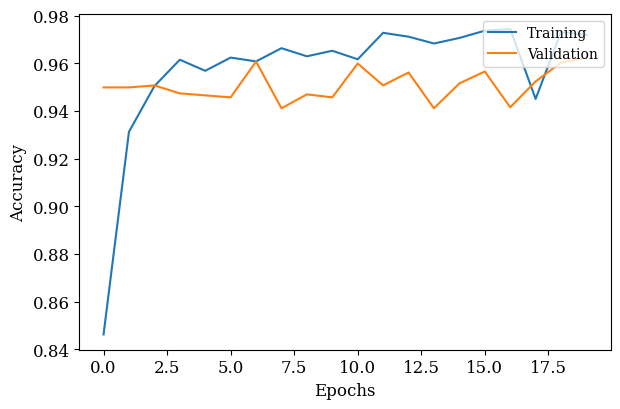

In [35]:
qualityLinePlot(history)